In [119]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import colors as mcolors
import corner
from scipy.interpolate import interp1d
from scipy import integrate
from pesummary.io import read
from simple_pe.param_est import SimplePESamples
from simple_pe import io
from simple_pe.param_est import find_metric_and_eigendirections, component_mass_prior_weight, loguniform_e_prior_weight

import logging
_logger = logging.getLogger('PESummary')
_logger.setLevel(logging.CRITICAL + 10)
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [138]:
samples_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/tests/ecc_ci_test/outdir/output/'

# Read in files
peak_path = os.path.join(samples_dir, 'peak_parameters.json')
with open(peak_path, 'r') as f:
    all_peak_params = json.load(f)
peak_snr_path = os.path.join(samples_dir, 'peak_snrs.json')
with open(peak_snr_path, 'r') as f:
    all_peak_snrs = json.load(f)
metric_path = os.path.join(samples_dir, 'analysis_metric.pkl')
with open(metric_path, 'rb') as f:
    metric = pickle.load(f)
p_path = os.path.join(samples_dir, 'posterior_samples.dat')
p_samples = SimplePESamples(read(p_path).samples_dict)
p_samples.generate_all_posterior_samples()

In [28]:
# # Create psds
# asds = {'H1': os.path.join(samples_dir, '../../aligo_O4high.txt'),
#         'L1': os.path.join(samples_dir, '../../aligo_O4high.txt'),
#         'V1': os.path.join(samples_dir, '../../avirgo_O4high_NEW.txt')}
# psds = io.load_psd_from_file(
#     [], asds, 1/32, 20, 2048
# )
# hm_psd = io.calculate_harmonic_mean_psd(psds)

In [16]:
# snr_22 = all_peak_snrs['posterior_samples']['22'][0]
# param_keys = ['ecc10sqrd', 'chirp_mass', 'symmetric_mass_ratio', 'chi_align']
# params = {key: all_peak_params['posterior_samples'][key][0] for key in param_keys}
# metric = find_metric_and_eigendirections(
#     params, ['ecc10sqrd', 'chirp_mass'], snr_22,
#     20, hm_psd,  'TEOBResumS-Dali-Harms', None, None,
#     0.01, 1, ncpus=1,
#     mute_multiprocessing=True, n_ecc_gen=6
# )

Failed to achieve requested tolerance.  Requested: 2.1e-05achieved 0.0006: 


241369


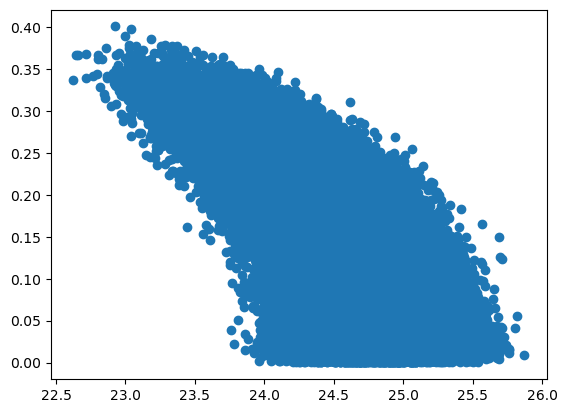

In [34]:
# Generate samples and reweight with prior
metric_samples = metric.generate_samples(10**8)
dx_directions = ['ecc10sqrd', 'chirp_mass', 'symmetric_mass_ratio', 'chi_align']
reweighted_metric_samples = component_mass_prior_weight(metric_samples, dx_directions)
reweighted_metric_samples = loguniform_e_prior_weight(reweighted_metric_samples, dx_directions)
print(len(reweighted_metric_samples['ecc10sqrd']))
plt.scatter(reweighted_metric_samples['chirp_mass'], reweighted_metric_samples['ecc10sqrd']**0.5)
plt.show()

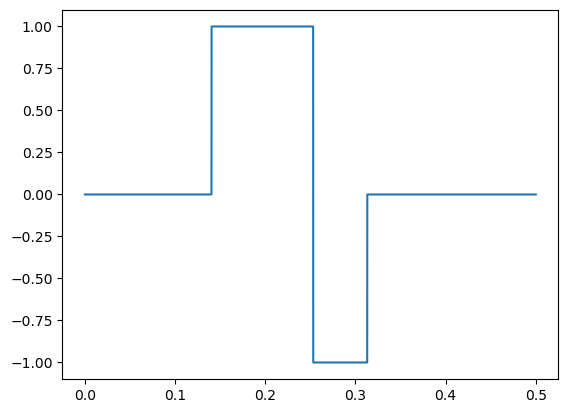

In [195]:
plt.plot(eccs[1:], np.sign(np.diff(ecc_weights)))
plt.show()

In [204]:
# Generate ecc weights
p_path = os.path.join(samples_dir, 'posterior_samples.dat')
p_samples = SimplePESamples(read(p_path).samples_dict)
p_samples.generate_all_posterior_samples()
ecc_weight_interp = interp1d(p_samples['ecc10'], p_samples['p_ecc']/np.max(p_samples['p_ecc']),
                             bounds_error=False, fill_value=0)
eccs = np.linspace(0, 0.5, 10**6)
ecc_weights = ecc_weight_interp(eccs)

# Calculate contour levels
def ecc_weight_contours(eccs, ecc_weights, cis):
    ci_eccs = []
    peak_arg = np.argmax(ecc_weights)
    for ci in cis:
        ci_eccs.append([])
        ci_eccs[-1].append(eccs[:peak_arg][np.argmin(np.abs(ecc_weights[:peak_arg]-ci))])
        ci_eccs[-1].append(eccs[peak_arg:][np.argmin(np.abs(ecc_weights[peak_arg:]-ci))])
    return ci_eccs
cis = np.linspace(0.1, 0.9, 9)
ci_eccs = ecc_weight_contours(eccs, ecc_weights, cis=cis)

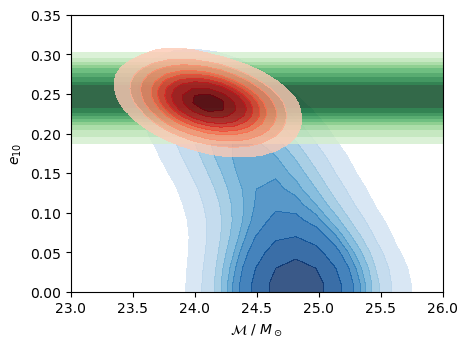

In [227]:
# Make plot
plt.figure(figsize=(0.75*6.4, 0.75*4.8))
xlims = [23, 26]
cmap = mpl.colormaps['Blues']
cs = cmap(np.linspace(0.2, 1, len(ci_eccs)))
cs = [mcolors.to_rgba(cmap(0), alpha=0)] + [mcolors.to_rgba(c, alpha=0.8) for c in cs]
corner.hist2d(reweighted_metric_samples['chirp_mass'], reweighted_metric_samples['ecc10sqrd']**0.5,
              plot_density=False, plot_contours=True, plot_datapoints=False, no_fill_contours=True, fill_contours=True,
              levels=np.linspace(0.1, 0.9, 9), smooth=2,
              contour_kwargs={'linewidths': 0}, contourf_kwargs={'colors': cs})
cmap = mpl.colormaps['Greens']
cs = cmap(np.linspace(0.2, 1, len(ci_eccs)))
for i, ci_ecc in enumerate(ci_eccs):
    if i != len(ci_eccs)-1:
        plt.fill_between(xlims, np.min(ci_ecc), np.min(ci_eccs[i+1]), linewidth=0, color=cs[i], alpha=0.8)
        plt.fill_between(xlims, np.max(ci_eccs[i+1]), np.max(ci_ecc), linewidth=0, color=cs[i], alpha=0.8)
    else:
        plt.fill_between(xlims, np.min(ci_ecc), np.max(ci_ecc), linewidth=0, color=cs[i], alpha=0.8)
cmap = mpl.colormaps['Reds']
cs = cmap(np.linspace(0.2, 1, len(ci_eccs)))
cs = [mcolors.to_rgba(cmap(0), alpha=0)] + [mcolors.to_rgba(c, alpha=0.8) for c in cs]
corner.hist2d(p_samples['chirp_mass'], p_samples['ecc10sqrd']**0.5,
              plot_density=False, plot_contours=True, plot_datapoints=False, no_fill_contours=True, fill_contours=True,
              levels=np.linspace(0.1, 0.9, 9), smooth=2,
              contour_kwargs={'linewidths': 0, 'linestyles': 'dotted', 'colors': cs}, contourf_kwargs={'colors': cs})
plt.xlim(xlims)
plt.ylim(0,0.35)
plt.xlabel('$\mathcal{M}~/~M_\odot$')
plt.ylabel('$e_{10}$')
plt.show()